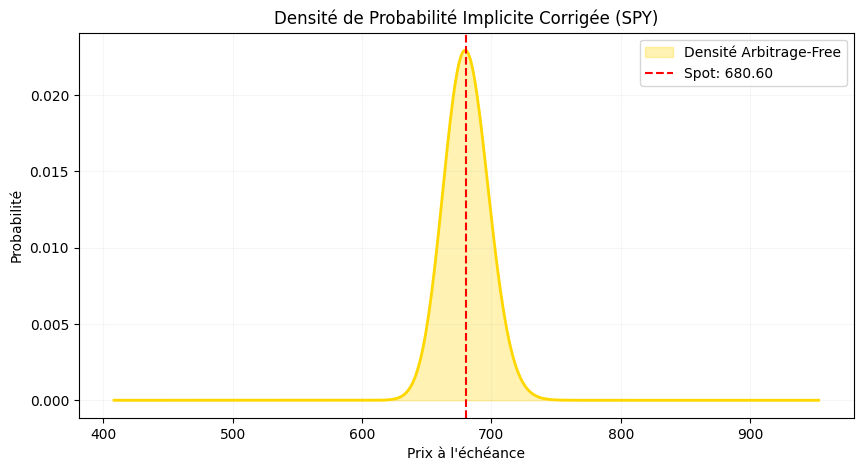

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.optimize import minimize
import scipy.stats as sps
import matplotlib.pyplot as plt

# --- 1. FORMULE SVI & OBJECTIF AVEC PÉNALITÉ DE CONVEXITÉ ---
def svi_formula(k, params):
    a, b, rho, m, sigma = params
    return a + b * (rho * (k - m) + np.sqrt((k - m)**2 + sigma**2))

def svi_objective_no_arbitrage(params, k, w_market, weights):
    a, b, rho, m, sigma = params
    
    # Contraintes sur les paramètres (Gatheral)
    if b < 0 or sigma < 0 or abs(rho) >= 1 or a + b * sigma * np.sqrt(1 - rho**2) < 0:
        return 1e12
    
    w_model = svi_formula(k, params)
    mse = np.sum(weights * (w_model - w_market)**2)
    
    # --- PÉNALITÉ DE DURRLEMAN (Non-Arbitrage Butterfly) ---
    # On teste la convexité sur une grille de log-strikes
    k_test = np.linspace(-1.0, 1.0, 100)
    w = svi_formula(k_test, params)
    
    dw = np.gradient(w, k_test)
    d2w = np.gradient(dw, k_test)
    
    # La fonction g(k) doit être >= 0 pour éviter les probabilités négatives
    g = (1 - k_test * dw / (2 * w))**2 - (dw**2 / (4 * w)) * (1/w + 4) + d2w / 2
    
    penalty = 0
    if np.any(g < 0):
        penalty = 1e6 * np.sum(np.abs(g[g < 0]))
        
    return mse + penalty

# --- 2. FONCTION DE CALIBRATION ---
def calibrate_and_plot_density(ticker_symbol):
    asset = yf.Ticker(ticker_symbol)
    S0 = asset.history(period="1d")['Close'].iloc[-1]
    
    exp = asset.options[3] # ~1 mois de maturité
    opt = asset.option_chain(exp)
    calls = opt.calls[(opt.calls['impliedVolatility'] > 0.01) & (opt.calls['openInterest'] > 5)].copy()
    
    T = (pd.to_datetime(exp) - pd.Timestamp.now()).days / 365.0
    k = np.log(calls['strike'] / S0).values
    w_market = (calls['impliedVolatility']**2).values * T
    weights = calls['openInterest'].values / np.sum(calls['openInterest'].values)
    
    initial_guess = [np.min(w_market), 0.1, -0.5, 0.0, 0.1]
    bounds = [(1e-7, 1.0), (1e-7, 2.0), (-0.99, 0.99), (-1.0, 1.0), (1e-7, 1.0)]
    
    res = minimize(svi_objective_no_arbitrage, initial_guess, args=(k, w_market, weights), 
                   method='L-BFGS-B', bounds=bounds)
    
    # --- EXTRACTION DE LA DENSITÉ (PDF) ---
    K_range = np.linspace(S0 * 0.6, S0 * 1.4, 500)
    k_grid = np.log(K_range / S0)
    w_svi = svi_formula(k_grid, res.x)
    iv_svi = np.sqrt(w_svi / T)
    
    # Prix des calls via BS pour dériver
    r = 0.043
    def bs_call(S, K, T, r, sigma):
        d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
        d2 = d1 - sigma*np.sqrt(T)
        return S * sps.norm.cdf(d1) - K * np.exp(-r*T) * sps.norm.cdf(d2)

    prices = np.array([bs_call(S0, Ki, T, r, si) for Ki, si in zip(K_range, iv_svi)])
    dK = K_range[1] - K_range[0]
    pdf = np.gradient(np.gradient(prices, dK), dK) * np.exp(r * T)
    
    # Nettoyage final : on force à 0 les résidus numériques infimes
    pdf = np.maximum(pdf, 0) 

    # --- PLOT ---
    plt.figure(figsize=(10, 5))
    plt.fill_between(K_range, pdf, color='gold', alpha=0.3, label='Densité Arbitrage-Free')
    plt.plot(K_range, pdf, color='gold', lw=2)
    plt.axvline(S0, color='red', linestyle='--', label=f'Spot: {S0:.2f}')
    plt.title(f"Densité de Probabilité Implicite Corrigée ({ticker_symbol})")
    plt.xlabel("Prix à l'échéance")
    plt.ylabel("Probabilité")
    plt.legend()
    plt.grid(True, alpha=0.1)
    plt.show()

# Run
calibrate_and_plot_density("SPY")